# Baseline: фичи из текста и JSON-атрибутов + LightGBM

План:
1. Загрузка `items_human` + `matches`, джойн текстов
2. Парсинг `attributes` (JSON) → структурные фичи пары (бренд, артикулы/OEM, KV-совпадения)
3. Текстовые фичи: TF-IDF косинусы (word + char), fuzzy-метрики, числовые токены
4. Стратифицированный сплит по категории × таргет
5. LightGBM → **macro PR-AUC** (как в соревновании)

Цель бейзлайна: рабочий пайплайн валидации и точка отсчёта перед трансформером.

## 0. Инициализация

In [1]:
import pandas as pd
import numpy as np
import json, re, collections
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import average_precision_score
import lightgbm as lgb
from rapidfuzz.distance import JaroWinkler
from rapidfuzz import fuzz
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
DATA = '..'
rng = np.random.RandomState(RANDOM_STATE)

## 1. Загрузка данных и джойн

In [2]:
items = pd.read_parquet(f'{DATA}/items_human.parquet')
matches = pd.read_parquet(f'{DATA}/matches.parquet')
print(items.shape, matches.shape)

(711304, 4) (365654, 3)


In [3]:
%%time
m = (matches
     .merge(items.add_suffix('_1'), left_on='id1', right_on='id_1', how='left')
     .merge(items.add_suffix('_2'), left_on='id2', right_on='id_2', how='left'))
assert m[['name_1','name_2']].notna().all().all()
print(m.shape)

(365654, 11)
CPU times: user 234 ms, sys: 139 ms, total: 373 ms
Wall time: 375 ms


In [4]:
# Предпарсинг attributes один раз на товар (не на пару!)
attr_cache = {i: (json.loads(a) if a else {})
              for i, a in zip(items['id'], items['attributes'])}
print('Товаров с непустыми атрибутами:', sum(bool(v) for v in attr_cache.values()))

Товаров с непустыми атрибутами: 711232


## 2. Структурные фичи из JSON-атрибутов

In [5]:
# Ключи с идентификаторами (артикулы/OEM) — самый сильный сигнал совпадения
ARTICLE_PAT = re.compile(r'артикул|oem|оем|партномер', re.I)
def get_articles(attr):
    arts = []
    for k, v in attr.items():
        if ARTICLE_PAT.search(k):
            arts.extend(x.strip().lower() for x in str(v).replace(',', ';').split(';') if x.strip())
    return set(arts)

BRAND_KEYS = ('бренд',)
COLOR_KEYS = ('цвет товара', 'цвет', 'название цвета')

norm = lambda s: re.sub(r'\s+', ' ', str(s).strip().lower())

item_arts = {i: get_articles(a) for i, a in attr_cache.items()}
item_brands = {i: next((norm(a[k]) for k in BRAND_KEYS if k in a), None) for i, a in attr_cache.items()}
item_colors = {i: next((norm(a[k]) for k in COLOR_KEYS if k in a), None) for i, a in attr_cache.items()}
print('С артикулами:', sum(bool(v) for v in item_arts.values()),
      '| С брендом:', sum(v is not None for v in item_brands.values()))

С артикулами: 153493 | С брендом: 369084


In [6]:
%%time
def struct_features(df):
    out = {}
    b1 = df['id1'].map(item_brands); b2 = df['id2'].map(item_brands)
    both_b = b1.notna() & b2.notna()
    out['brand_both_missing'] = (~both_b).astype(np.int8)
    out['brand_eq'] = np.where(both_b & (b1 == b2), 1, 0)
    out['brand_neq'] = np.where(both_b & (b1 != b2), 1, 0)

    c1 = df['id1'].map(item_colors); c2 = df['id2'].map(item_colors)
    both_c = c1.notna() & c2.notna()
    out['color_eq'] = np.where(both_c & (c1 == c2), 1, 0)
    out['color_neq'] = np.where(both_c & (c1 != c2), 1, 0)

    a1 = df['id1'].map(item_arts); a2 = df['id2'].map(item_arts)
    inter = np.array([len(x & y) for x, y in zip(a1, a2)], dtype=np.float32)
    union = np.array([len(x | y) for x, y in zip(a1, a2)], dtype=np.float32)
    out['art_inter'] = (inter > 0).astype(np.int8)
    out['art_inter_cnt'] = inter
    out['art_jaccard'] = np.where(union > 0, inter / np.maximum(union, 1), 0)

    # Точные совпадения key->value по всем атрибутам
    d1 = df['id1'].map(attr_cache); d2 = df['id2'].map(attr_cache)
    kv_eq, kv_min, jac = [], [], []
    for x, y in zip(d1, d2):
        ks = set(x) | set(y)
        eq = sum(1 for k in ks if norm(x.get(k)) == norm(y.get(k)) and k in x and k in y)
        common = len(set(x) & set(y))
        kv_eq.append(eq); kv_min.append(eq / max(min(len(x), len(y)), 1)); jac.append(common / max(len(ks), 1))
    out['kv_exact'] = np.array(kv_eq, dtype=np.float32)
    out['kv_exact_frac'] = np.array(kv_min, dtype=np.float32)
    out['keys_jaccard'] = np.array(jac, dtype=np.float32)
    return pd.DataFrame(out, index=df.index)

struct_f = struct_features(m)
struct_f.describe().round(3).T

CPU times: user 9.37 s, sys: 114 ms, total: 9.49 s
Wall time: 9.53 s


,count,mean,std,min,25%,50%,75%,max
brand_both_missing,365654.0,0.868,0.339,0.0,1.000,1.000,1.000,1.0
brand_eq,365654.0,0.073,0.260,0.0,0.000,0.000,0.000,1.0
brand_neq,365654.0,0.059,0.237,0.0,0.000,0.000,0.000,1.0
color_eq,365654.0,0.128,0.335,0.0,0.000,0.000,0.000,1.0
color_neq,365654.0,0.244,0.429,0.0,0.000,0.000,0.000,1.0
art_inter,365654.0,0.004,0.065,0.0,0.000,0.000,0.000,1.0
art_inter_cnt,365654.0,0.007,0.360,0.0,0.000,0.000,0.000,189.0
art_jaccard,365654.0,0.002,0.042,0.0,0.000,0.000,0.000,1.0
kv_exact,365654.0,0.633,0.987,0.0,0.000,0.000,1.000,10.0
kv_exact_frac,365654.0,0.068,0.120,0.0,0.000,0.000,0.100,1.0


In [7]:
# Проверим силу артикульных фичей по отдельности
for col in ['art_inter', 'brand_eq', 'brand_neq']:
    t = m['target'].values
    v = struct_f[col].values
    print(col, '| mean(target)=', t[v==1].mean().round(3), f'(v=1)', t[v==0].mean().round(3), '(v=0)')

art_inter | mean(target)= 0.882 (v=1) 0.254 (v=0)
brand_eq | mean(target)= 0.249 (v=1) 0.257 (v=0)
brand_neq | mean(target)= 0.244 (v=1) 0.258 (v=0)


## 3. Текстовые фичи

In [8]:
%%time
# TF-IDF на всех названиях товаров (711k) — word + char
corpus = items['name'].fillna('').tolist()
ids_arr = items['id'].values
pos_of = {i: p for p, i in enumerate(ids_arr)}

tf_word = TfidfVectorizer(max_features=50_000, sublinear_tf=True).fit(corpus)
Xw = tf_word.transform(corpus)

tf_char = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), max_features=200_000,
                          sublinear_tf=True).fit(corpus)
Xc = tf_char.transform(corpus)
print(Xw.shape, Xc.shape)

(711304, 50000) (711304, 200000)
CPU times: user 53 s, sys: 1.1 s, total: 54.1 s
Wall time: 54.4 s


In [9]:
%%time
def pairwise_cos(X, i1, i2):
    A = X[i1]; B = X[i2]
    dot = np.asarray(A.multiply(B).sum(axis=1)).ravel()
    na = np.sqrt(np.asarray(A.multiply(A).sum(axis=1))).ravel()
    nb = np.sqrt(np.asarray(B.multiply(B).sum(axis=1))).ravel()
    return dot / np.maximum(na * nb, 1e-9)

pos1 = m['id1'].map(pos_of).values
pos2 = m['id2'].map(pos_of).values
text_f = pd.DataFrame({
    'cos_word': pairwise_cos(Xw, pos1, pos2),
    'cos_char': pairwise_cos(Xc, pos1, pos2),
}, index=m.index)
text_f.describe().round(3)

CPU times: user 899 ms, sys: 228 ms, total: 1.13 s
Wall time: 1.15 s


,cos_word,cos_char
count,365654.000,365654.000
mean,0.556,0.550
std,0.273,0.250
min,0.000,0.000
25%,0.355,0.371
50%,0.585,0.573
75%,0.775,0.744
max,1.000,1.000


In [10]:
%%time
# Fuzzy и числовые фичи
n1 = m['name_1'].fillna('').tolist(); n2 = m['name_2'].fillna('').tolist()
num_re = re.compile(r'\d+(?:[.,]\d+)?')
nums = []
for a, b in zip(n1, n2):
    ta = [float(x.replace(',', '.')) for x in num_re.findall(a)]
    tb = [float(x.replace(',', '.')) for x in num_re.findall(b)]
    nums.append((ta, tb))

text_f['jw'] = [JaroWinkler.normalized_similarity(a, b) for a, b in zip(n1, n2)]
text_f['fuzz_ratio'] = [fuzz.ratio(a, b) / 100 for a, b in zip(n1, n2)]
text_f['fuzz_token_sort'] = [fuzz.token_sort_ratio(a, b) / 100 for a, b in zip(n1, n2)]
text_f['len_ratio'] = [min(len(a), len(b)) / max(len(a), len(b), 1) for a, b in zip(n1, n2)]
text_f['nums_inter'] = [len(set(a) & set(b)) for a, b in nums]
text_f['nums_union'] = [len(set(a) | set(b)) for a, b in nums]
print(text_f.shape)

(365654, 8)
CPU times: user 2.75 s, sys: 71.5 ms, total: 2.82 s
Wall time: 2.83 s


## 4. Валидация: стратификация категория × таргет

In [11]:
y = m['target'].values
strat = m['category_1'] + '_' + m['target'].astype(int).astype(str)
val_frac = 0.2
idx_val = (m.groupby(strat).cumcount() / m.groupby(strat)['id1'].transform('size')).values < val_frac
# Проще и надёжнее — sklearn стратифицированный сплит:
from sklearn.model_selection import StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, test_size=val_frac, random_state=RANDOM_STATE)
train_idx, val_idx = next(sss.split(m, strat))
print(f'train={len(train_idx):,} val={len(val_idx):,}')
assert abs(y[val_idx].mean() - y[train_idx].mean()) < 0.01

train=292,523 val=73,131


In [12]:
def macro_ap(y_true, scores, cats, verbose=True):
    res = {}
    for c in np.unique(cats):
        mask = cats == c
        res[c] = average_precision_score(y_true[mask], scores[mask])
    if verbose:
        for c, v in sorted(res.items(), key=lambda x: x[1]):
            print(f'{v:.4f}  {c}')
    return np.mean(list(res.values()))

cats = m['category_1'].values

## 5. Обучение LightGBM

In [13]:
FEAT_NAMES = struct_f.columns.tolist() + text_f.columns.tolist()
X_all = pd.concat([struct_f, text_f], axis=1)[FEAT_NAMES]
X_tr, y_tr = X_all.iloc[train_idx], y[train_idx]
X_va, y_va = X_all.iloc[val_idx], y[val_idx]

model = lgb.LGBMClassifier(
    n_estimators=2000, learning_rate=0.05, num_leaves=63,
    colsample_bytree=0.8, subsample=0.8, subsample_freq=1,
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
)
model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric='average_precision',
          callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])
print('best iteration:', model.best_iteration_)

Training until validation scores don't improve for 100 rounds


Early stopping, best iteration is:
[1205]	valid_0's average_precision: 0.599492	valid_0's binary_logloss: 0.450158
best iteration: 1205


In [14]:
scores = model.predict_proba(X_va)[:, 1]
ap = average_precision_score(y_va, scores)
macro = macro_ap(y_va, scores, cats[val_idx])
print(f'\nMicro PR-AUC: {ap:.4f}')
print(f'MACRO PR-AUC (метрика соревнования): {macro:.4f}')

0.2712  Ювелирные изделия
0.2789  Обувь
0.2845  Одежда
0.4582  Галантерея и аксессуары
0.4610  Электроника
0.4809  Мебель
0.4943  Спорт и отдых
0.5359  Аптека
0.5416  Автотовары
0.5503  Продукты питания
0.5537  Канцелярские товары
0.5625  Строительство и ремонт
0.5641  Дом и сад
0.5929  Музыкальные инструменты
0.5990  Красота и гигиена
0.6249  Товары для животных
0.6522  Бытовая техника
0.6625  Бытовая химия
0.7735  Хобби и творчество
0.7799  Детские товары

Micro PR-AUC: 0.5995
MACRO PR-AUC (метрика соревнования): 0.5361


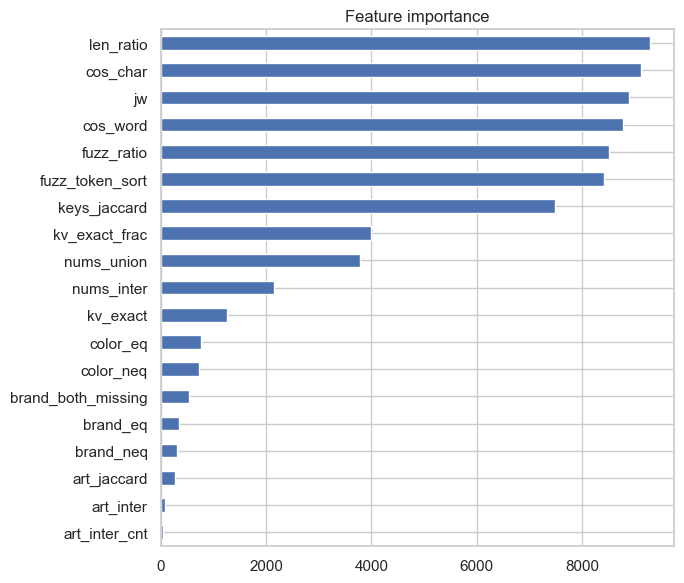

len_ratio             9281
cos_char              9111
jw                    8900
cos_word              8771
fuzz_ratio            8515
fuzz_token_sort       8417
keys_jaccard          7483
kv_exact_frac         3985
nums_union            3780
nums_inter            2150
kv_exact              1262
color_eq               761
color_neq              723
brand_both_missing     529
brand_eq               347
brand_neq              316
art_jaccard            261
art_inter               75
art_inter_cnt           43
dtype: int32


In [15]:
imp = pd.Series(model.feature_importances_, index=FEAT_NAMES).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7,6))
imp.plot.barh(ax=ax); ax.invert_yaxis(); ax.set_title('Feature importance')
plt.tight_layout(); plt.show()
print(imp)

In [16]:
# Ошибка по парам категорий: где модель слабее всего
per_cat = pd.Series({c: average_precision_score(
    y_va[cats[val_idx]==c], scores[cats[val_idx]==c]) for c in np.unique(cats)})
base_rate = pd.Series({c: y_va[cats[val_idx]==c].mean() for c in np.unique(cats)})
pd.DataFrame({'pr_auc': per_cat, 'positive_rate': base_rate}).sort_values('pr_auc')

,pr_auc,positive_rate
Ювелирные изделия,0.271205,0.123830
Обувь,0.278901,0.098829
Одежда,0.284525,0.117748
Галантерея и аксессуары,0.458207,0.167640
Электроника,0.461016,0.172645
Мебель,0.480919,0.150014
Спорт и отдых,0.494330,0.259667
Аптека,0.535874,0.072484
Автотовары,0.541640,0.174908
Продукты питания,0.550336,0.270440


## Выводы
Заполнить после прогона:
- Macro PR-AUC бейзлайна
- Самые сильные фичи (ожидаемо cos_char, артикулы, fuzzy)
- Слабые категории — кандидаты на внимание при переходе к трансформеру